ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance (1).csv


![step1.png](attachment:step1.png)

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [ ]:
# Load Dataset
df = pd.read_csv("StudentsPerformance.csv")
df.head()
# Display first 5 rows.

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Check Missing Values

In [ ]:
# Check all values
print(df.isna())

     gender  race/ethnicity  parental level of education  lunch  \
0     False           False                        False  False   
1     False           False                        False  False   
2     False           False                        False  False   
3     False           False                        False  False   
4     False           False                        False  False   
..      ...             ...                          ...    ...   
995   False           False                        False  False   
996   False           False                        False  False   
997   False           False                        False  False   
998   False           False                        False  False   
999   False           False                        False  False   

     test preparation course  math score  reading score  writing score  
0                      False       False          False          False  
1                      False       False         

In [ ]:
print(df.isna().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


### Check duplicate rows

In [ ]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0


Removing any duplication

### No. of rows and columns

In [ ]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (1000, 8) 

number of rows:  1000
number of columns:  8


### Data type of columns

In [ ]:
# viewing the data types of columns
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [ ]:
df['gender'] = df['gender'].str.strip()
df['race/ethnicity'] = df['race/ethnicity'].str.strip()
df['parental level of education'] = df['parental level of education'].str.strip()
df['lunch'] = df['lunch'].str.strip()
df['test preparation course'] = df['test preparation course'].str.strip()

df['math score'] = pd.to_numeric(df['math score'], errors='coerce')
df['reading score'] = pd.to_numeric(df['reading score'], errors='coerce')
df['writing score'] = pd.to_numeric(df['writing score'], errors='coerce')
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


To improve data consistency, extra spaces in categorical columns such as gender, race/ethnicity, parental level of education, lunch, and test preparation course were removed using string operations (str.strip()).

In addition, numerical columns including math score, reading score, and writing score were verified and converted to numeric format using pd.to_numeric() to ensure they are suitable for analysis.

These cleaning steps were necessary to avoid inconsistencies and ensure accurate and reliable results during the exploratory data analysis process.

In [ ]:
# Statistical summary
df.describe(include='all')

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


### Descriptive summary Statistics

### Univariate Analysis

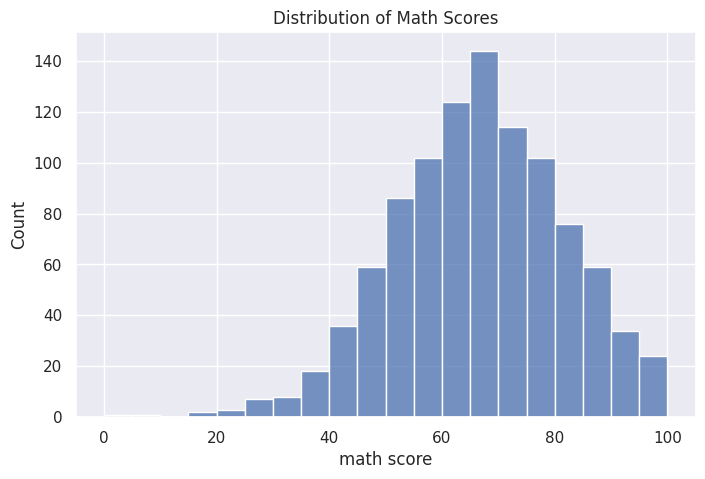

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['math score'], bins=20)
plt.title("Distribution of Math Scores")
plt.show()

This histogram shows the distribution of math scores among students. Most students scored between 60 and 80, indicating an average performance level. The distribution appears approximately normal, with fewer students scoring very low or very high marks.

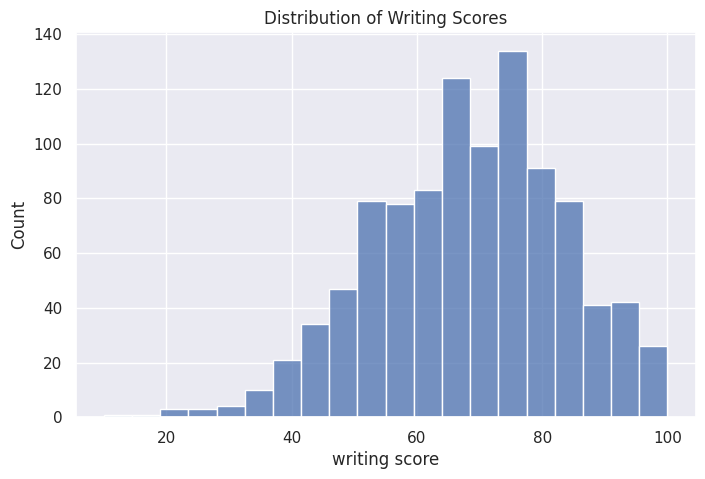

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['writing score'], bins=20)
plt.title("Distribution of Writing Scores")
plt.show()

This histogram shows the distribution of writing scores among students. Most students scored between 65 and 85, indicating generally good performance in writing. The distribution is skewed to the left.

### Distribution of Revenue

Since this dataset does not include revenue data, score distributions are used instead to analyze student performance.

## Bivariate Analysis

### Gender vs Math Score

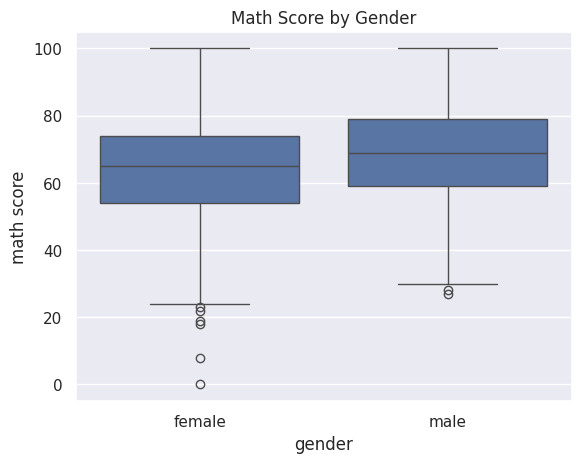

In [18]:
sns.boxplot(x='gender', y='math score', data=df)
plt.title("Math Score by Gender")
plt.show()

This boxplot compares math scores between male and female students. The median scores are quite similar, but male students appear to have slightly higher scores overall.

### Test Preparation vs Scores

>



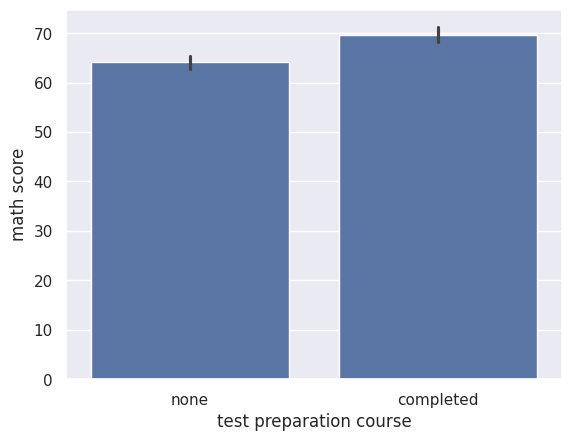

In [19]:
sns.barplot(x='test preparation course', y='math score', data=df)
plt.show()

This bar chart shows that students who completed the test preparation course have higher math scores compared to those who did not. This indicates that the preparation course has a positive impact on performance.

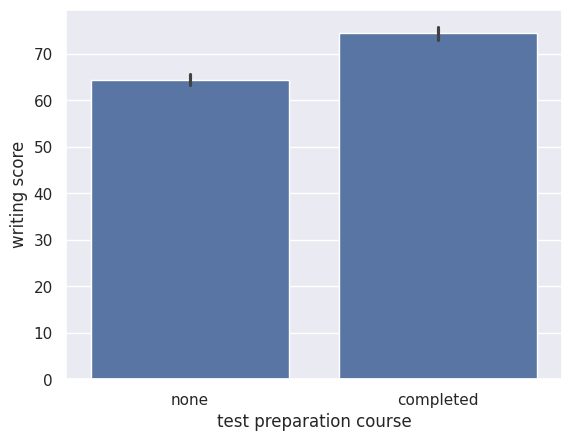

In [21]:
sns.barplot(x='test preparation course', y='writing score', data=df)
plt.show()

This chart shows that students who completed the test preparation course achieved higher writing scores

### Reading vs Writing

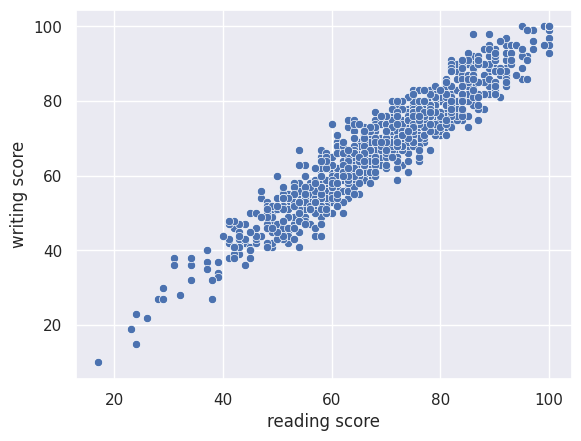

In [20]:
sns.scatterplot(x='reading score', y='writing score', data=df)
plt.show()

This scatter plot shows a strong positive relationship between reading and writing scores. Students with higher reading scores tend to also have higher writing scores.

### Parental Education vs Math Score

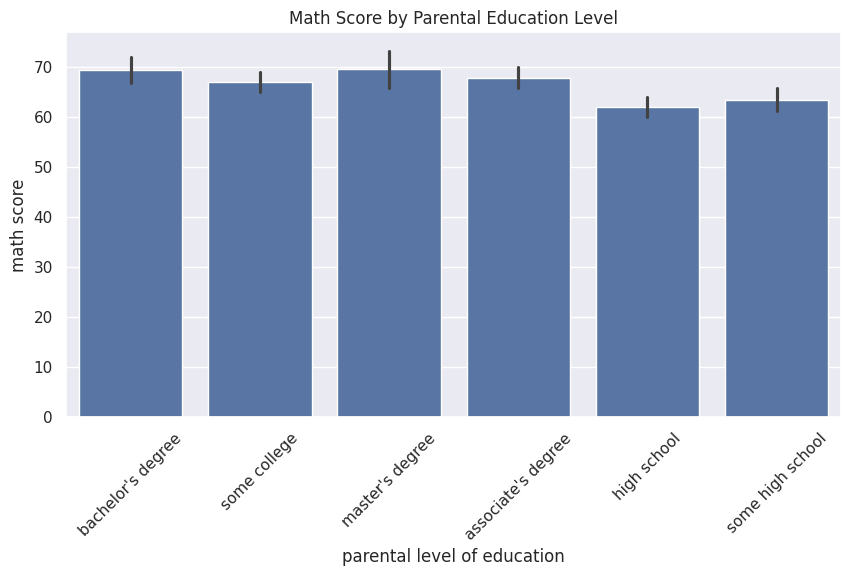

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(x='parental level of education', y='math score', data=df)
plt.xticks(rotation=45)
plt.title("Math Score by Parental Education Level")
plt.show()

Students with higher parental education levels tend to achieve better math scores.


### Correlation Matrix

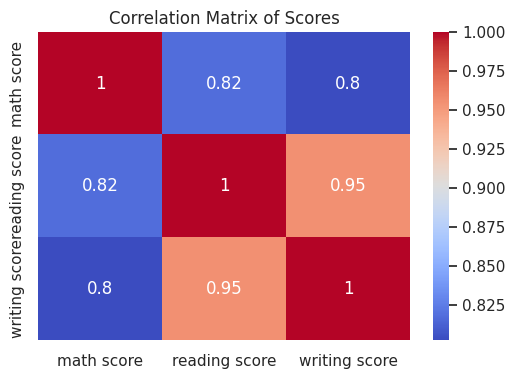

In [23]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Scores")
plt.show()

Correlation close to 1 indicates a strong positive relationship. In this dataset, reading and writing scores have a very strong positive correlation (0.95), while math scores also show a strong positive relationship with both reading (0.82) and writing (0.80).

## Time-Based Analysis
###

This dataset does not contain time-related features; therefore, time-based analysis is not applicable.

**Statistical Summary of scores**

Mean Score Analysis

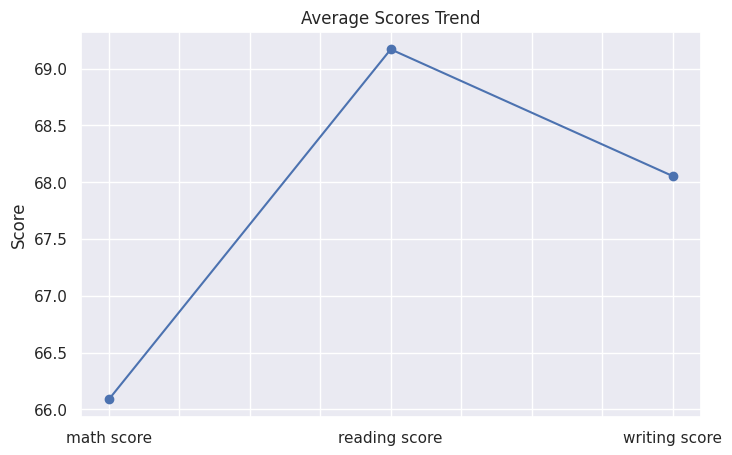

In [25]:
avg_scores = df[['math score', 'reading score', 'writing score']].mean()

plt.figure(figsize=(8,5))
avg_scores.plot(marker='o')
plt.title("Average Scores Trend")
plt.ylabel("Score")
plt.show()

The chart shows that reading scores are the highest, while math scores are the lowest among the subjects.

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
